# Practice Lab Assignment 1 -Neural Network Implementation from Scratch

**Student Information:**
* **Name of Student:** Gandhar Sunil Chafle
* **PRN Number:** 202401110018
* **Batch:** A2
* **Date of Submission:** 15 August 2026
* **Class:** S.Y. B.Tech
* **Department:** CSE AIML
* **Institute:** MIT Academy of Engineering (MIT AOE)
* **Course:** Generative AI Lab

## 1. Problem Definition
 **Dataset:** Iris Dataset

## 2. Methodology

### Neural Network Architecture
**Input Layer:** 4 neurons to accept the 4 input features\
**Hidden Layer:** 1 hidden layer containing 8 neurons\
**Activation Function:** ReLU $f(x) = \max(0, x)$ \
**Output Layer:** 3 neurons for the 3 target classes\
**Activation Function:** Softmax $\sigma(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$

### Forward Pass
1. **Hidden Layer:** $Z^{[1]} = XW^{[1]} + b^{[1]}$, followed by $A^{[1]} = \text{ReLU}(Z^{[1]})$ 
2. **Output Layer:** $Z^{[2]} = A^{[1]}W^{[2]} + b^{[2]}$, followed by $A^{[2]} = \text{Softmax}(Z^{[2]})$ 

### Backpropagation & Optimization
**Loss Function:** Categorical Cross-Entropy $\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{C} y_{ik} \log(\hat{y}_{ik})$ \
**Optimization:** Gradient Descent $W = W - \alpha \cdot dW$ 

#Code (Data Preparation)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
y = iris.target

y_encoded = np.zeros((len(y), 3))

for i in range(len(y)):
    if y[i] == 0:
        y_encoded[i] = [1, 0, 0]
    elif y[i] == 1:
        y_encoded[i] = [0, 1, 0]
    elif y[i] == 2:
        y_encoded[i] = [0, 0, 1]

mean_X = np.mean(X, axis=0)
std_X = np.std(X, axis=0)

# Formula: Z = (X - mu) / sigma
X = (X - mean_X) / std_X

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

#Code (Network Implementation)

In [3]:
class SimpleNeuralNetwork:
    def __init__(self, input_nodes, hidden_nodes, output_nodes, learning_rate=0.01):
        self.lr = learning_rate
        np.random.seed(42)

        self.w1 = np.random.randn(input_nodes, hidden_nodes) * 0.1
        self.b1 = np.zeros((1, hidden_nodes))

        self.w2 = np.random.randn(hidden_nodes, output_nodes) * 0.1
        self.b2 = np.zeros((1, output_nodes))

    def relu(self, z):
        return np.maximum(0, z) #f(z) = max(0, z)

    def relu_deriv(self, z):
        return z > 0   #f'(z) = 1 if z > 0 else 0

    def softmax(self, z):
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def cross_entropy_loss(self, y_true, y_pred):
        m = len(y_true)
        loss = - (1/m) * np.sum(y_true * np.log(y_pred + 1e-9))
        return loss

    def forward(self, X):
        # Formula: Z1 = X \cdot W1 + b1
        self.z1 = np.dot(X, self.w1) + self.b1
        self.a1 = self.relu(self.z1)

        # Formula: Z2 = A1 \cdot W2 + b2
        self.z2 = np.dot(self.a1, self.w2) + self.b2
        self.a2 = self.softmax(self.z2)

        return self.a2

    def backward(self, X, y_true):
        m = len(X)

        # Formula: dZ2 = A2 - Y
        error_output = self.a2 - y_true
        dw2 = (1/m) * np.dot(self.a1.T, error_output)
        db2 = (1/m) * np.sum(error_output, axis=0, keepdims=True)

        # Formula: dZ1 = (dZ2 \cdot W2^T) * f'(Z1)
        error_hidden = np.dot(error_output, self.w2.T) * self.relu_deriv(self.z1)
        dw1 = (1/m) * np.dot(X.T, error_hidden)
        db1 = (1/m) * np.sum(error_hidden, axis=0, keepdims=True)

        # Formula: W = W - \alpha \cdot dW
        self.w1 = self.w1 - (self.lr * dw1)
        self.b1 = self.b1 - (self.lr * db1)
        self.w2 = self.w2 - (self.lr * dw2)
        self.b2 = self.b2 - (self.lr * db2)

    def train(self, X, y_true, epochs=1000):
        losses = []
        for epoch in range(epochs):
            self.forward(X)
            self.backward(X, y_true)

            if epoch % 50 == 0:
                loss = self.cross_entropy_loss(y_true, self.a2)
                losses.append(loss)

        return losses

    def predict(self, X):
        predictions = self.forward(X)
        return np.argmax(predictions, axis=1)

#Code (Training and Evaluation)

In [6]:
inputs = 4
hidden = 8
outputs = 3
nn = SimpleNeuralNetwork(inputs, hidden, outputs, learning_rate=0.1)

epochs_count = 1500
training_loss = nn.train(X_train, y_train, epochs=epochs_count)

train_preds = nn.predict(X_train)
test_preds = nn.predict(X_test)

y_train_actual = np.argmax(y_train, axis=1)
y_test_actual = np.argmax(y_test, axis=1)

cans = 0
totalque = len(test_preds)

for i in range(totalque):
    if test_preds[i] == y_test_actual[i]:
        cans += 1

test_acc = (cans / totalque) * 100

print(f"Total Correct answers in test: {cans} out of {totalque}")
print(f"Final testing accuracy: {test_acc:.2f}%")

Total Correct answers in test: 30 out of 30
Final testing accuracy: 100.00%


#Code (Visualizations)

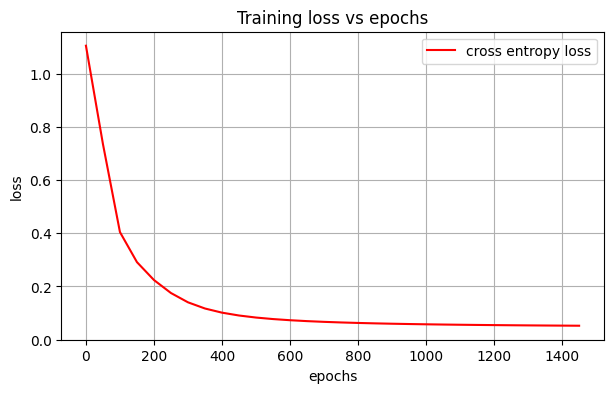

In [10]:
plt.figure(figsize=(7, 4))
epoch_ticks = np.arange(0, epochs_count, 50)
plt.plot(epoch_ticks, training_loss, label='cross entropy loss', color='red')

plt.title('Training loss vs epochs')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid(True)
plt.legend()
plt.show()


#3. Analysis of the Implemented Model
**Model Behavior:**
Looking at the loss curve, gradient descent is working as expected. The error drops really fast in the first few hundred epochs and then flattens out. Because our testing accuracy is high, we know the 8-neuron hidden layer actually learned the patterns instead of just memorizing (overfitting) the training data.

**Comparison with Alternative Models:**
Even though building this from scratch was great for understanding the math behind deep learning, a neural network is honestly overkill for a small dataset like Iris (only 150 rows). Simpler models like Random Forest or Logistic Regression would give similar results much faster, and we wouldn't have to manually tune things like the learning rate or number of epochs.

#4. Evaluate Performance of Deep Learning Models
Overall, the model performed really well. Using ReLU in the hidden layer helped the network learn non-linear patterns, and Softmax at the end gave us clear percentage probabilities for the three flower species. Even though standard machine learning is better for simple datasets, building this from scratch helped me understand the core math and architecture we will need for more complex AI tasks later on.

## Declaration
I, Gandhar Sunil Chafle, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the
repository link is provided below:

**GitHub Repository Link:** https://github.com/ChafleGandhar-16/Generative-AI/tree/main/Practical-1

**Signature:** Gandhar Sunil Chafle